In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential 
import matplotlib.pyplot as plt

In [3]:
raw_data = pd.read_csv("weatherHistory.csv")
raw_data

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [5]:
dataset = raw_data.drop(["Formatted Date", "Summary", "Precip Type", "Loud Cover", "Daily Summary"], axis=1)
dataset

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51
...,...,...,...,...,...,...,...
96448,26.016667,26.016667,0.43,10.9963,31.0,16.1000,1014.36
96449,24.583333,24.583333,0.48,10.0947,20.0,15.5526,1015.16
96450,22.038889,22.038889,0.56,8.9838,30.0,16.1000,1015.66
96451,21.522222,21.522222,0.60,10.5294,20.0,16.1000,1015.95


In [7]:
non_target_features = dataset.drop(["Humidity"], axis=1)
target_feature = dataset["Humidity"]

In [9]:
# Split 80 : 10 : 10
x_train, x_temp, y_train, y_temp = train_test_split(non_target_features, target_feature, test_size=0.2, random_state=127)

x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=127)

In [10]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)
scaled_x_val = scaler.transform(x_val)

In [25]:
# model = Sequential([
#     Dense(32, activation="relu", input_dim = scaled_x_train.shape[1]),
#     Dense(16, activation="relu"),
#     Dense(8, activation="relu"),
#     Dense(1, activation="linear"),
# ])

model = Sequential([
    Dense(128, activation="relu", input_dim = scaled_x_train.shape[1]), 
    Dropout(0.3),
    Dense(64, activation="relu"), 
    Dropout(0.5),
    Dense(32, activation="relu"), 
    Dropout(0.5),
    Dense(1, activation="linear"),
])

model.compile(optimizer="adam", loss="mae", metrics=["mean_squared_error"])

In [ ]:
history = model.fit(scaled_x_train, y_train, epochs=1200, batch_size=256, validation_data=(scaled_x_val, y_val))

Epoch 1/1200
302/302 [==============================] - 1s 3ms/step - loss: 0.2476 - mean_squared_error: 0.1112 - val_loss: 0.1465 - val_mean_squared_error: 0.0282
Epoch 2/1200
302/302 [==============================] - 1s 2ms/step - loss: 0.1539 - mean_squared_error: 0.0371 - val_loss: 0.1146 - val_mean_squared_error: 0.0191
Epoch 3/1200
302/302 [==============================] - 1s 2ms/step - loss: 0.1304 - mean_squared_error: 0.0271 - val_loss: 0.1079 - val_mean_squared_error: 0.0178
Epoch 4/1200
302/302 [==============================] - 1s 3ms/step - loss: 0.1166 - mean_squared_error: 0.0220 - val_loss: 0.1051 - val_mean_squared_error: 0.0179
Epoch 5/1200
302/302 [==============================] - 2s 5ms/step - loss: 0.1095 - mean_squared_error: 0.0198 - val_loss: 0.1046 - val_mean_squared_error: 0.0180
Epoch 6/1200
302/302 [==============================] - 2s 6ms/step - loss: 0.1054 - mean_squared_error: 0.0188 - val_loss: 0.0981 - val_mean_squared_error: 0.0163
Epoch 7/1200
302

In [14]:
model.evaluate(scaled_x_test, y_test)

302/302 [==============================] - 1s 5ms/step - loss: 0.0797 - mean_squared_error: 0.0119


[0.07966001331806183, 0.011946790851652622]

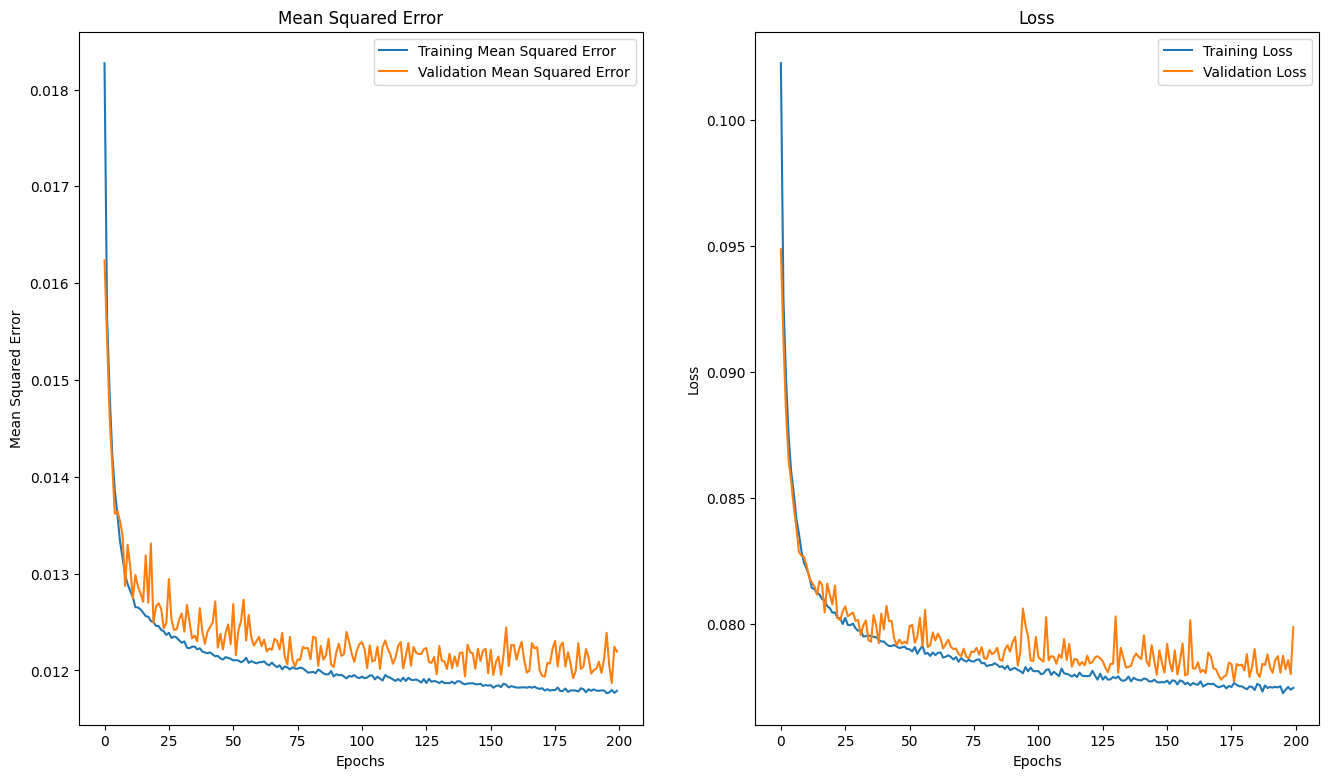

In [15]:
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
plt.plot(history.history['mean_squared_error'], label="Training Mean Squared Error")
plt.plot(history.history['val_mean_squared_error'], label="Validation Mean Squared Error")
plt.title("Mean Squared Error")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [21]:
predict = model.predict(scaled_x_test)
for i, value in enumerate(predict[:20]):
    value = value.item()
    print(f"Actual: {y_test.iloc[i]} - Predicted: {value:.2f}")

302/302 [==============================] - 1s 3ms/step
Actual: 0.69 - Predicted: 0.75
Actual: 0.81 - Predicted: 0.87
Actual: 0.77 - Predicted: 0.79
Actual: 0.66 - Predicted: 0.73
Actual: 0.93 - Predicted: 0.87
Actual: 0.78 - Predicted: 0.89
Actual: 0.93 - Predicted: 0.78
Actual: 0.89 - Predicted: 0.85
Actual: 0.81 - Predicted: 0.82
Actual: 0.88 - Predicted: 0.74
Actual: 1.0 - Predicted: 0.97
Actual: 0.81 - Predicted: 0.83
Actual: 0.58 - Predicted: 0.68
Actual: 0.45 - Predicted: 0.43
Actual: 0.86 - Predicted: 0.87
Actual: 0.35 - Predicted: 0.57
Actual: 0.97 - Predicted: 0.98
Actual: 0.54 - Predicted: 0.51
Actual: 0.45 - Predicted: 0.48
Actual: 0.89 - Predicted: 0.80
